# 🎭 Face2FaceRHO — 영상 멀티 얼굴 스왑 (메타데이터 기반)

> ⚠️ **런타임 설정 먼저!** 상단 메뉴 → 런타임 → 런타임 유형 변경 → **GPU (T4)** 선택

## 파이프라인 개요
```
face_meta.mp4 (driving 영상)
    + metadata.json (tracking_id별 bbox + pts_us)
    + source.jpg (공통 source 이미지)
        ↓
  [방식 A] Face2FaceRHO reenact.py → 고품질 표정 전달
  [방식 B] face_alignment + seamlessClone → 빠른 landmark 기반 합성
        ↓
  output_frames/ → output.mp4 + output_frames/ 저장
```

## 사용 파일
| 파일 | 설명 |
|------|------|
| `face_meta.mp4` | driving 영상 (~34초) |
| `metadata.json` | 793 프레임, 25개 tracking_id, bbox + pts_us |
| `source.jpg` | 교체할 얼굴 source (일단 전체 ID 동일 적용) |

---
## ⚙️ STEP 0 — 환경 확인

In [ ]:
!nvidia-smi
import torch, sys
print(f"Python  : {sys.version}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.version.cuda}")
print(f"GPU 사용: {torch.cuda.is_available()}")

Tue Mar 24 07:10:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## 📁 STEP 1 — 레포 클론 + 패키지 설치

In [ ]:
import os

if not os.path.exists('/content/Face2FaceRHO'):
    !git clone https://github.com/NetEase-GameAI/Face2FaceRHO.git
else:
    print("이미 클론됨 — 스킵")

%cd /content/Face2FaceRHO
!git submodule update --init --recursive
print("✅ 클론 완료")

Cloning into 'Face2FaceRHO'...
remote: Enumerating objects: 119, done.
remote: Counting objects: 100% (119/119), done.
remote: Compressing objects: 100% (111/111), done.
remote: Total 119 (delta 8), reused 116 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (119/119), 6.61 MiB | 39.81 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/Face2FaceRHO
✅ 클론 완료


In [ ]:
# 기본 패키지
!pip install -q kornia yacs ninja trimesh
!pip install -q face-alignment==1.3.4
!pip install -q opencv-python-headless imageio imageio-ffmpeg
print("✅ 패키지 설치 완료")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 132.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ 패키지 설치 완료


---
## 🗂️ STEP 2 — 모델 파일 준비

> ### ⚠️ 수동 다운로드 필요 (3가지)
>
> | # | 모델 | 링크 | 저장 위치 |
> |---|------|------|----------|
> | 1 | **Pre-trained weights** | [Google Drive](https://drive.google.com/drive/folders/1eKHMevJBIvjLcVBBB2EkJwHkzN7pTLJG) | `./src/checkpoints/voxceleb_face2facerho/` |
> | 2 | **FLAME 2020** | [flame.is.tue.mpg.de](https://flame.is.tue.mpg.de/) (회원가입 필요) | `./src/external/data/generic_model.pkl` |
> | 3 | **DECA model** | [DECA GitHub](https://github.com/yfeng95/DECA) → README Downloads | `./src/external/data/deca_model.tar` |
>
> **권장**: 파일을 구글 드라이브에 업로드 후 아래 셀에서 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, shutil

# =============================================
# ↓ 본인의 드라이브 경로로 수정하세요
DRIVE_BASE = '/content/drive/MyDrive/Face2FaceRHO_models'
# =============================================

os.makedirs('./src/checkpoints/voxceleb_face2facerho', exist_ok=True)
os.makedirs('./src/external/data', exist_ok=True)

tasks = [
    (f'{DRIVE_BASE}/voxceleb_face2facerho', './src/checkpoints/', 'dir'),
    (f'{DRIVE_BASE}/generic_model.pkl',     './src/external/data/generic_model.pkl', 'file'),
    (f'{DRIVE_BASE}/deca_model.tar',        './src/external/data/deca_model.tar', 'file'),
]

for src, dst, kind in tasks:
    if os.path.exists(src):
        if kind == 'dir':
            shutil.copytree(src, dst + os.path.basename(src), dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)
        print(f"✅ 복사 완료: {os.path.basename(src)}")
    else:
        print(f"❌ 파일 없음: {src}")

✅ 복사 완료: voxceleb_face2facerho
✅ 복사 완료: generic_model.pkl
✅ 복사 완료: deca_model.tar


In [ ]:
# 모델 파일 존재 여부 확인
checks = [
    './src/checkpoints/voxceleb_face2facerho',
    './src/external/data/generic_model.pkl',
    './src/external/data/deca_model.tar',
]
all_ok = True
for p in checks:
    ok = os.path.exists(p)
    print(f"{'✅' if ok else '❌'} {p}")
    if not ok: all_ok = False
print()
print("🚀 모든 파일 준비 완료!" if all_ok else "⛔ 위 ❌ 항목을 먼저 해결하세요.")

✅ ./src/checkpoints/voxceleb_face2facerho
✅ ./src/external/data/generic_model.pkl
✅ ./src/external/data/deca_model.tar

🚀 모든 파일 준비 완료!


---
## 📤 STEP 3 — 입력 파일 설정

- **source 이미지**: Face2FaceRHO 레포의 `test_case/source/source.jpg` 사용 (레포 클론 후 자동 경로)
- **driving 영상 + 메타데이터**: 모델 파일과 같은 Drive 폴더(`DRIVE_BASE`)에서 가져옴
  - 아래 셀에서 `DRIVE_BASE` 경로와 파일명을 확인 후 수정하세요

In [ ]:
# Drive 폴더 내 파일 목록 확인
import os

# =============================================
# ↓ STEP 2에서 설정한 DRIVE_BASE와 동일한 경로
# =============================================
DRIVE_BASE = '/content/drive/MyDrive/Face2FaceRHO_models'

print("Drive 폴더 내 파일 목록:")
if os.path.exists(DRIVE_BASE):
    for f in sorted(os.listdir(DRIVE_BASE)):
        size = os.path.getsize(os.path.join(DRIVE_BASE, f))
        print(f"  {f}  ({size/1024/1024:.1f} MB)")
else:
    print(f"❌ {DRIVE_BASE} 경로가 없습니다. Drive 마운트(STEP 2)를 먼저 실행하세요.")

Drive 폴더 내 파일 목록:
  deca_model.tar  (414.0 MB)
  face_meta.mp4  (13.1 MB)
  generic_model.pkl  (50.6 MB)
  metadata_1774237242321.json  (3.0 MB)
  voxceleb_face2facerho  (0.0 MB)


In [ ]:
import os, glob, shutil

# =============================================
# ↓ 위 셀에서 확인한 파일명으로 수정하세요
# =============================================
DRIVING_VIDEO_NAME  = 'face_meta.mp4'                    # driving 영상 파일명
METADATA_JSON_NAME  = 'metadata_1774237242321.json'       # 메타데이터 파일명
# =============================================

# Drive → /content 로 복사 (반복 실행 시 스킵)
DRIVING_VIDEO = f'/content/{DRIVING_VIDEO_NAME}'
METADATA_JSON = f'/content/{METADATA_JSON_NAME}'

for name, dst in [(DRIVING_VIDEO_NAME, DRIVING_VIDEO), (METADATA_JSON_NAME, METADATA_JSON)]:
    src_path = f'{DRIVE_BASE}/{name}'
    if not os.path.exists(dst):
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst)
            print(f'✅ 복사 완료: {name}')
        else:
            print(f'❌ Drive에서 파일을 찾을 수 없음: {src_path}')
    else:
        print(f'⏭️  이미 존재 — 스킵: {dst}')

# source 이미지: 레포 클론 후 test_case 경로 사용
SOURCE_IMG_DEFAULT = '/content/Face2FaceRHO/test_case/source/source.jpg'

# tracking_id별 다른 source를 쓰고 싶을 때만 아래를 채우세요
# 비워두면 SOURCE_IMG_DEFAULT 를 전체 ID에 적용
SOURCE_PER_ID = {
    # 예시: 0: '/content/drive/MyDrive/Face2FaceRHO_models/source_A.jpg',
    #       2: '/content/drive/MyDrive/Face2FaceRHO_models/source_B.jpg',
}

# 출력 경로
OUTPUT_DIR   = '/content/output_frames'
OUTPUT_VIDEO = '/content/output.mp4'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 최종 확인
for label, path in [('driving', DRIVING_VIDEO), ('metadata', METADATA_JSON), ('source', SOURCE_IMG_DEFAULT)]:
    ok = os.path.exists(path)
    print(f"{'✅' if ok else '❌'} {label}: {path}")

✅ 복사 완료: face_meta.mp4
✅ 복사 완료: metadata_1774237242321.json
✅ driving: /content/face_meta.mp4
✅ metadata: /content/metadata_1774237242321.json
✅ source: /content/Face2FaceRHO/test_case/source/source.jpg


---
## 🔍 STEP 4 — 메타데이터 분석 + 프레임 추출

In [ ]:
import json
import numpy as np
from collections import defaultdict, Counter

# 메타데이터 로드
with open(METADATA_JSON) as f:
    meta = json.load(f)

frames_meta = meta['frames']
frames_with_faces = [f for f in frames_meta if f['faces']]

# tracking_id 통계
id_counter = Counter()
for frame in frames_with_faces:
    for face in frame['faces']:
        id_counter[face['tracking_id']] += 1

print(f"전체 프레임 수   : {len(frames_meta)}")
print(f"얼굴 있는 프레임 : {len(frames_with_faces)}")
print(f"tracking_id 수   : {len(id_counter)}")
print()
print("tracking_id별 등장 프레임 수:")
for tid, count in sorted(id_counter.items()):
    bar = '█' * (count // 10)
    print(f"  ID {tid:3d}: {count:4d}프레임  {bar}")

전체 프레임 수   : 793
얼굴 있는 프레임 : 628
tracking_id 수   : 25

tracking_id별 등장 프레임 수:
  ID   0:  348프레임  ██████████████████████████████████
  ID   2:  142프레임  ██████████████
  ID   6:   17프레임  █
  ID   7:   42프레임  ████
  ID   8:    4프레임  
  ID   9:  147프레임  ██████████████
  ID  10:    5프레임  
  ID  11:   19프레임  █
  ID  14:    1프레임  
  ID  15:   23프레임  ██
  ID  17:   39프레임  ███
  ID  21:   37프레임  ███
  ID  22:   96프레임  █████████
  ID  24:   45프레임  ████
  ID  25:   33프레임  ███
  ID  26:    7프레임  
  ID  29:   22프레임  ██
  ID  30:    3프레임  
  ID  33:   23프레임  ██
  ID  34:   33프레임  ███
  ID  35:  134프레임  █████████████
  ID  42:   15프레임  █
  ID  51:    1프레임  
  ID  61:   41프레임  ████
  ID  76:   15프레임  █


In [ ]:
import cv2

# =============================================
# driving 영상에서 프레임 추출
# pts_us(마이크로초) 기준으로 메타데이터 매핑
# =============================================

FRAMES_DIR = '/content/driving_frames'
os.makedirs(FRAMES_DIR, exist_ok=True)

cap = cv2.VideoCapture(DRIVING_VIDEO)
fps        = cap.get(cv2.CAP_PROP_FPS)
total_frm  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"FPS: {fps:.2f}  총 프레임: {total_frm}  해상도: {width}x{height}")

# pts_us 리스트 (메타데이터 순서와 프레임 인덱스를 맞춤)
pts_list = [f['pts_us'] for f in frames_meta]
pts_min  = pts_list[0]

# 프레임별로 pts_us → 가장 가까운 메타 인덱스 매핑 테이블 생성
# pts_us를 마이크로초→초로 변환하여 영상 프레임 번호 추산
meta_frame_index = {}  # {video_frame_idx: meta_frame_idx}
for mi, frame_info in enumerate(frames_meta):
    t_sec   = (frame_info['pts_us'] - pts_min) / 1e6
    v_idx   = round(t_sec * fps)
    if 0 <= v_idx < total_frm:
        meta_frame_index[v_idx] = mi

# 프레임 추출 (메타가 있는 프레임만 저장)
saved = 0
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
for vi in range(total_frm):
    ret, frame = cap.read()
    if not ret:
        break
    if vi in meta_frame_index:
        cv2.imwrite(f"{FRAMES_DIR}/frame_{vi:06d}.jpg", frame)
        saved += 1

cap.release()
print(f"✅ 저장된 프레임: {saved}/{total_frm}")

FPS: 23.01  총 프레임: 792  해상도: 1280x720
✅ 저장된 프레임: 749/792


---
## 🅐 방식 A — Face2FaceRHO reenact.py (고품질, 느림)

tracking_id별로 crop된 얼굴을 face_alignment로 landmark 추출 후 `reenact.py`에 전달합니다.

In [ ]:
# =============================================
# [방식 A - 준비] source 이미지 landmark 미리 추출
# =============================================

import face_alignment
import numpy as np
import cv2
import os

# 이 픽셀 미만의 bbox(width 또는 height)는 swap 건너뜀
MIN_FACE_PX = 80  # ← 필요에 따라 조정 (픽셀)

fa = face_alignment.FaceAlignment(
    face_alignment.LandmarksType._2D, device='cuda'
)

# def extract_landmarks_txt(img_path, out_lm_path, out_hp_path):
#     """
#     Face2FaceRHO load_landmarks / load_coeffs 호환 포맷:
#       landmark.txt : 68줄, 각 줄 → 'x y' (공백 구분)
#         load_landmarks: s1 = line.split(), s1[0]=x, s1[1]=y
#       headpose.txt  : 3줄, 각 줄 → float 하나
#         load_coeffs : float(line)
#     """
#     img = cv2.imread(img_path)
#     if img is None:
#         return False
#     img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     lms = fa.get_landmarks(img_rgb)
#     if lms is None:
#         return False
#     lm = lms[0]  # (68, 2) — x, y

#     # landmark.txt: 68줄, 줄마다 'x y'
#     with open(out_lm_path, 'w') as f:
#         for x, y in lm:
#             f.write(f'{x:.6f} {y:.6f}\n')

#     # headpose.txt: pitch yaw roll 각각 한 줄
#     with open(out_hp_path, 'w') as f:
#         for v in [0.0, 0.0, 0.0]:
#             f.write(f'{v:.6f}\n')
#     return True

def expand_68_to_72(lm68):
    # 임시로 4개 점 추가
    extra = lm68[[30, 33, 48, 54], :]   # 코, 입 주변 점 복제
    lm72 = np.vstack([lm68, extra])
    return lm72

def extract_landmarks_txt(img_path, out_lm_path, out_hp_path):
    img = cv2.imread(img_path)
    if img is None:
        return False

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lms = fa.get_landmarks(img_rgb)
    if lms is None:
        return False

    lm = lms[0]              # (68, 2)
    lm = expand_68_to_72(lm) # (72, 2)

    with open(out_lm_path, 'w') as f:
        for x, y in lm:
            f.write(f'{x:.6f} {y:.6f}\n')

    with open(out_hp_path, 'w') as f:
        for v in [0.0, 0.0, 0.0]:
            f.write(f'{v:.6f}\n')

    return True

# source 이미지 landmark 추출
SRC_LM_DIR = '/content/Face2FaceRHO/custom_input/source'
os.makedirs(SRC_LM_DIR, exist_ok=True)

ok = extract_landmarks_txt(
    SOURCE_IMG_DEFAULT,
    f'{SRC_LM_DIR}/landmark.txt',
    f'{SRC_LM_DIR}/headpose.txt'
)
if ok:
    print('✅ source landmark 추출 완료')
    with open(f'{SRC_LM_DIR}/landmark.txt') as f:
        ll = f.readlines()
    with open(f'{SRC_LM_DIR}/headpose.txt') as f:
        hl = f.readlines()
    print(f'  landmark.txt : {len(ll)}줄  예시 → {ll[0].strip()}')
    print(f'  headpose.txt : {len(hl)}줄  예시 → {hl[0].strip()}')
else:
    print('❌ source에서 얼굴을 찾지 못했습니다')


✅ source landmark 추출 완료
  landmark.txt : 72줄  예시 → 140.000000 217.000000
  headpose.txt : 3줄  예시 → 0.000000


In [ ]:
import subprocess
import shutil

def run_reenact_on_crop(crop_img_path, crop_lm_path, crop_hp_path, out_path):
    """
    crop된 driving 얼굴에 대해 reenact.py 실행.
    결과 이미지를 out_path에 저장.
    """
    result_dir = '/content/Face2FaceRHO/custom_input/result_tmp'
    os.makedirs(result_dir, exist_ok=True)

    cmd = [
        'python', 'src/reenact.py',
        '--config', './src/config/test_face2facerho.ini',
        '--src_img',       SOURCE_IMG_DEFAULT,
        '--src_headpose',  f'{SRC_LM_DIR}/headpose.txt',
        '--src_landmark',  f'{SRC_LM_DIR}/landmark.txt',
        '--drv_headpose',  crop_hp_path,
        '--drv_landmark',  crop_lm_path,
        '--output_dir',    result_dir,
    ]

    res = subprocess.run(cmd, capture_output=True, text=True,
                         cwd='/content/Face2FaceRHO')
    if res.returncode != 0:
        print(f"  ⚠️  reenact 실패: {res.stderr[-200:]}")
        return False

    result_img = os.path.join(result_dir, 'result.png')
    if os.path.exists(result_img):
        shutil.copy2(result_img, out_path)
        return True
    return False


def get_source_img_for_id(tracking_id):
    """tracking_id에 해당하는 source 이미지 반환. 없으면 default 사용."""
    return SOURCE_PER_ID.get(tracking_id, SOURCE_IMG_DEFAULT)


def blend_reenacted_face(frame_bgr, reenacted_bgr, bbox, margin=0.2):
    """
    reenact 결과를 원본 프레임의 bbox 위치에 seamlessClone으로 합성.
    bbox: {'x', 'y', 'width', 'height'}
    """
    x, y, w, h = bbox['x'], bbox['y'], bbox['width'], bbox['height']
    mx = int(w * margin)
    my = int(h * margin)
    x1 = max(0, x - mx);  y1 = max(0, y - my)
    x2 = min(frame_bgr.shape[1], x + w + mx)
    y2 = min(frame_bgr.shape[0], y + h + my)
    rw, rh = x2 - x1, y2 - y1

    # reenacted 이미지를 crop 크기로 리사이즈
    rn = cv2.resize(reenacted_bgr, (rw, rh))

    # 타원 마스크
    mask = np.zeros((rh, rw), dtype=np.uint8)
    cx, cy = rw // 2, rh // 2
    cv2.ellipse(mask, (cx, cy), (cx - 4, cy - 4), 0, 0, 360, 255, -1)
    mask = cv2.GaussianBlur(mask, (21, 21), 11)

    # seamlessClone (중심 좌표는 원본 프레임 기준)
    center = (x1 + cx, y1 + cy)
    try:
        out = cv2.seamlessClone(rn, frame_bgr, mask, center, cv2.NORMAL_CLONE)
        return out
    except Exception as e:
        print(f"    seamlessClone 오류: {e}")
        return frame_bgr


print("✅ 방식 A 함수 정의 완료")

✅ 방식 A 함수 정의 완료


In [ ]:
import os
import json
import numpy as np

# -----------------------------
# 1) json 로드
# -----------------------------
META_JSON = '/content/metadata_1774237242321.json'   # 경로 수정
OUT_DIR = '/content/converted_meta'
os.makedirs(OUT_DIR, exist_ok=True)

with open(META_JSON, 'r') as f:
    meta = json.load(f)

frames = meta["frames"] if isinstance(meta, dict) and "frames" in meta else meta

# -----------------------------
# 2) 68 -> 72 확장용 landmark 템플릿
#    bbox 안에서 대충 얼굴 모양으로 배치
# -----------------------------
def make_bbox_landmarks_72(bbox):
    x, y, w, h = bbox["x"], bbox["y"], bbox["width"], bbox["height"]

    pts = []

    # jawline 17점
    for i in range(17):
        px = x + w * (0.08 + 0.84 * i / 16.0)
        py = y + h * (0.78 + 0.10 * abs(i - 8) / 8.0)
        pts.append([px, py])

    # left eyebrow 5
    for i in range(5):
        px = x + w * (0.18 + 0.18 * i / 4.0)
        py = y + h * (0.28 - 0.03 * np.sin(i / 4.0 * np.pi))
        pts.append([px, py])

    # right eyebrow 5
    for i in range(5):
        px = x + w * (0.64 + 0.18 * i / 4.0)
        py = y + h * (0.28 - 0.03 * np.sin(i / 4.0 * np.pi))
        pts.append([px, py])

    # nose bridge 4
    for i in range(4):
        px = x + w * 0.50
        py = y + h * (0.34 + 0.16 * i / 3.0)
        pts.append([px, py])

    # nose bottom 5
    nose_bottom = [
        [0.40, 0.56], [0.46, 0.60], [0.50, 0.61], [0.54, 0.60], [0.60, 0.56]
    ]
    for rx, ry in nose_bottom:
        pts.append([x + w * rx, y + h * ry])

    # left eye 6
    left_eye = [
        [0.28, 0.40], [0.33, 0.37], [0.38, 0.40],
        [0.38, 0.44], [0.33, 0.46], [0.28, 0.44]
    ]
    for rx, ry in left_eye:
        pts.append([x + w * rx, y + h * ry])

    # right eye 6
    right_eye = [
        [0.62, 0.40], [0.67, 0.37], [0.72, 0.40],
        [0.72, 0.44], [0.67, 0.46], [0.62, 0.44]
    ]
    for rx, ry in right_eye:
        pts.append([x + w * rx, y + h * ry])

    # outer mouth 12
    outer_mouth = [
        [0.32, 0.72], [0.38, 0.68], [0.45, 0.66], [0.50, 0.66],
        [0.55, 0.66], [0.62, 0.68], [0.68, 0.72], [0.62, 0.76],
        [0.55, 0.79], [0.50, 0.80], [0.45, 0.79], [0.38, 0.76]
    ]
    for rx, ry in outer_mouth:
        pts.append([x + w * rx, y + h * ry])

    # inner mouth 8
    inner_mouth = [
        [0.40, 0.72], [0.46, 0.70], [0.50, 0.70], [0.54, 0.70],
        [0.60, 0.72], [0.54, 0.75], [0.50, 0.75], [0.46, 0.75]
    ]
    for rx, ry in inner_mouth:
        pts.append([x + w * rx, y + h * ry])

    pts = np.array(pts, dtype=np.float32)  # 68점

    # 72점으로 확장: 임시 복제
    extra = pts[[30, 33, 48, 54], :]
    pts72 = np.vstack([pts, extra])
    return pts72

# -----------------------------
# 3) coeffs -> headpose 6차원
#    마지막 6개를 pose라고 가정
# -----------------------------
def coeffs_to_headpose6(coeffs):
    coeffs = np.array(coeffs, dtype=np.float32)
    if len(coeffs) >= 6:
        hp = coeffs[-6:]
    else:
        hp = np.zeros(6, dtype=np.float32)
        hp[:len(coeffs)] = coeffs
    return hp

# -----------------------------
# 4) 프레임별 / 얼굴별 txt 저장
# -----------------------------
for fi, frame in enumerate(frames):
    faces = frame.get("faces", [])
    for face in faces:
        tid = face["tracking_id"]
        bbox = face["bbox"]
        coeffs = face["tdmm_raw"]["coeffs"]

        face_dir = os.path.join(OUT_DIR, f'frame_{fi:06d}_tid_{tid}')
        os.makedirs(face_dir, exist_ok=True)

        # landmark.txt
        lm72 = make_bbox_landmarks_72(bbox)
        with open(os.path.join(face_dir, 'landmark.txt'), 'w') as f:
            for x, y in lm72:
                f.write(f'{x:.6f} {y:.6f}\n')

        # headpose.txt
        hp6 = coeffs_to_headpose6(coeffs)
        with open(os.path.join(face_dir, 'headpose.txt'), 'w') as f:
            for v in hp6:
                f.write(f'{float(v):.6f}\n')

print('✅ 임시 변환 완료')

✅ 임시 변환 완료


In [ ]:
lm = np.loadtxt(f'{SRC_LM_DIR}/landmark.txt')
print(lm.shape)

(72, 2)


In [ ]:
# =============================================
# [방식 A - 실행] 프레임별 face swap 메인 루프
# =============================================

import glob

MAX_FRAMES = None  # None이면 전체. 테스트시 예: 50

OUTPUT_DIR_A = '/content/output_frames_A'
os.makedirs(OUTPUT_DIR_A, exist_ok=True)

DRV_TMP_DIR = '/content/drv_tmp'
os.makedirs(DRV_TMP_DIR, exist_ok=True)

frame_files = sorted(glob.glob(f'{FRAMES_DIR}/frame_*.jpg'))
if MAX_FRAMES:
    frame_files = frame_files[:MAX_FRAMES]

print(f"처리할 프레임: {len(frame_files)}")
skipped_small = 0
skipped_lm    = 0
skipped_reen  = 0
swapped       = 0

for ff in frame_files:
    vi = int(os.path.basename(ff).split('_')[1].split('.')[0])
    mi = meta_frame_index.get(vi)
    if mi is None:
        continue

    frame_info = frames_meta[mi]
    frame_bgr  = cv2.imread(ff)
    result_bgr = frame_bgr.copy()

    for face in frame_info['faces']:
        tid  = face['tracking_id']
        bbox = face['bbox']
        w_bb, h_bb = bbox['width'], bbox['height']

        # ── 너무 작은 얼굴 skip
        if w_bb < MIN_FACE_PX or h_bb < MIN_FACE_PX:
            skipped_small += 1
            continue

        # bbox crop (margin 포함)
        margin = 0.3
        x, y = bbox['x'], bbox['y']
        mx = int(w_bb * margin);  my = int(h_bb * margin)
        x1 = max(0, x - mx);     y1 = max(0, y - my)
        x2 = min(frame_bgr.shape[1], x + w_bb + mx)
        y2 = min(frame_bgr.shape[0], y + h_bb + my)

        crop = frame_bgr[y1:y2, x1:x2]
        if crop.shape[0] < MIN_FACE_PX or crop.shape[1] < MIN_FACE_PX:
            skipped_small += 1
            continue

        crop_path = f'{DRV_TMP_DIR}/crop_{vi:06d}_{tid}.jpg'
        cv2.imwrite(crop_path, crop)

        # driving landmark 추출
        lm_path = f'{DRV_TMP_DIR}/lm_{vi:06d}_{tid}.txt'
        hp_path = f'{DRV_TMP_DIR}/hp_{vi:06d}_{tid}.txt'
        ok = extract_landmarks_txt(crop_path, lm_path, hp_path)
        if not ok:
            skipped_lm += 1
            continue

        # reenact 실행
        reen_path = f'{DRV_TMP_DIR}/reen_{vi:06d}_{tid}.png'
        success = run_reenact_on_crop(crop_path, lm_path, hp_path, reen_path)
        if not success:
            skipped_reen += 1
            continue

        # 결과 blending
        reenacted = cv2.imread(reen_path)
        result_bgr = blend_reenacted_face(result_bgr, reenacted, bbox)
        swapped += 1

    out_frame_path = f'{OUTPUT_DIR_A}/frame_{vi:06d}.jpg'
    cv2.imwrite(out_frame_path, result_bgr)

    if vi % 30 == 0:
        print(f"  프레임 {vi:06d} | swap:{swapped} skip_small:{skipped_small} skip_lm:{skipped_lm} skip_reen:{skipped_reen}")

print(f"✅ 방식 A 완료 | swap:{swapped} / skip_small:{skipped_small} / skip_lm:{skipped_lm} / skip_reen:{skipped_reen}")


처리할 프레임: 749
  프레임 000000 | swap:0 skip_small:0 skip_lm:0 skip_reen:0
  프레임 000030 | swap:0 skip_small:46 skip_lm:0 skip_reen:0
  프레임 000060 | swap:0 skip_small:122 skip_lm:0 skip_reen:0
  프레임 000090 | swap:0 skip_small:181 skip_lm:1 skip_reen:0
  프레임 000120 | swap:0 skip_small:240 skip_lm:2 skip_reen:0
  프레임 000150 | swap:0 skip_small:301 skip_lm:7 skip_reen:0
  프레임 000180 | swap:0 skip_small:371 skip_lm:21 skip_reen:0
  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead



/usr/local/lib/python3.12/dist-packages/face_alignment/api.py:132: UserWarning: No faces were detected.
  warnings.warn("No faces were detected.")


  프레임 000210 | swap:0 skip_small:437 skip_lm:49 skip_reen:1
  프레임 000240 | swap:0 skip_small:489 skip_lm:79 skip_reen:1
  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️

/usr/local/lib/python3.12/dist-packages/face_alignment/api.py:132: UserWarning: No faces were detected.
  warnings.warn("No faces were detected.")


  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead



...

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of 

/usr/local/lib/python3.12/dist-packages/face_alignment/api.py:132: UserWarning: No faces were detected.
  warnings.warn("No faces were detected.")


  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of 

/usr/local/lib/python3.12/dist-packages/face_alignment/api.py:132: UserWarning: No faces were detected.
  warnings.warn("No faces were detected.")


  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of size [6, 64, 4, 4], expected input[1, 3, 1, 1] to have 6 channels, but got 3 channels instead

  ⚠️  reenact 실패:     return F.conv_transpose2d(
           ^^^^^^^^^^^^^^^^^^^
RuntimeError: Given transposed=1, weight of 

In [ ]:
import glob

# 방식 A — 결과 프레임을 mp4로 합치기
OUTPUT_VIDEO_A = '/content/output_A.mp4'

frame_files_A = sorted(glob.glob(f'{OUTPUT_DIR_A}/frame_*.jpg'))
print(f"합칠 프레임 수: {len(frame_files_A)}")

if frame_files_A:
    sample = cv2.imread(frame_files_A[0])
    h, w   = sample.shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    vw     = cv2.VideoWriter(OUTPUT_VIDEO_A, fourcc, fps, (w, h))

    for fp in frame_files_A:
        frm = cv2.imread(fp)
        vw.write(frm)
    vw.release()

    # mp4v → h264 재인코딩 (Colab 미리보기 호환)
    !ffmpeg -y -i {OUTPUT_VIDEO_A} -vcodec libx264 -crf 18 /content/output_A_h264.mp4 -loglevel error
    print(f"✅ 방식 A 영상 저장 완료: /content/output_A_h264.mp4")
else:
    print("❌ 처리된 프레임이 없습니다")

합칠 프레임 수: 749
✅ 방식 A 영상 저장 완료: /content/output_A_h264.mp4


---
## 🅑 방식 B — face_alignment + seamlessClone (빠름)

Face2FaceRHO를 거치지 않고 face_alignment로 landmark를 추출 →  
convex hull 마스크 → seamlessClone으로 source 얼굴을 driving bbox에 직접 합성합니다.

In [ ]:
import cv2
import numpy as np
import face_alignment
import glob
import os

fa = face_alignment.FaceAlignment(
    face_alignment.LandmarksType._2D, device='cuda'
)

# source 이미지 미리 읽어두기
src_bgr = cv2.imread(SOURCE_IMG_DEFAULT)
src_rgb = cv2.cvtColor(src_bgr, cv2.COLOR_BGR2RGB)
src_lms = fa.get_landmarks(src_rgb)

if src_lms is None:
    print("❌ source 이미지에서 얼굴을 찾지 못했습니다. 이미지를 확인하세요.")
else:
    print(f"✅ source landmark 추출 완료 (포인트 수: {src_lms[0].shape[0]})")


def get_face_mask_from_lm(shape, landmarks, scale=0.92):
    """landmark convex hull 기반 소프트 마스크 생성."""
    hull   = cv2.convexHull(landmarks.astype(np.int32)).squeeze()
    center = np.mean(hull, axis=0)
    hull_s = ((hull - center) * scale + center).astype(np.int32)
    mask   = np.zeros(shape[:2], dtype=np.uint8)
    cv2.fillConvexPoly(mask, hull_s, 255)
    mask   = cv2.GaussianBlur(mask, (21, 21), 11)
    return mask


def swap_face_method_b(frame_bgr, bbox, src_bgr_full, margin=0.35):
    """
    방식 B:
    1. source 이미지를 bbox 크기에 맞게 리사이즈
    2. driving crop에서 landmark 추출 → convex hull 마스크
    3. seamlessClone으로 원본 프레임에 합성
    """
    x, y, w, h = bbox['x'], bbox['y'], bbox['width'], bbox['height']
    mx = int(w * margin);  my = int(h * margin)
    x1 = max(0, x - mx);  y1 = max(0, y - my)
    x2 = min(frame_bgr.shape[1], x + w + mx)
    y2 = min(frame_bgr.shape[0], y + h + my)
    rw, rh = x2 - x1, y2 - y1

    if rw < 10 or rh < 10:
        return frame_bgr

    # driving crop에서 landmark 추출
    crop     = frame_bgr[y1:y2, x1:x2]
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    lms      = fa.get_landmarks(crop_rgb)

    if lms is None:
        # landmark 못 찾으면 단순 alpha blend fallback
        src_resized = cv2.resize(src_bgr_full, (rw, rh))
        mask_fb     = np.zeros((rh, rw), dtype=np.uint8)
        cx, cy      = rw // 2, rh // 2
        cv2.ellipse(mask_fb, (cx, cy), (cx - 6, cy - 6), 0, 0, 360, 255, -1)
        mask_fb = cv2.GaussianBlur(mask_fb, (21, 21), 11)
        center  = (x1 + cx, y1 + cy)
        try:
            return cv2.seamlessClone(src_resized, frame_bgr, mask_fb, center, cv2.NORMAL_CLONE)
        except:
            return frame_bgr

    lm   = lms[0]  # (68, 2)
    mask = get_face_mask_from_lm(crop.shape, lm)

    # source를 crop 크기로 리사이즈
    src_resized = cv2.resize(src_bgr_full, (rw, rh))

    center = (x1 + rw // 2, y1 + rh // 2)
    try:
        out = cv2.seamlessClone(src_resized, frame_bgr, mask, center, cv2.NORMAL_CLONE)
        return out
    except Exception as e:
        print(f"    seamlessClone 오류: {e}")
        return frame_bgr


print("✅ 방식 B 함수 정의 완료")

In [ ]:
# =============================================
# [방식 B - 실행] 프레임별 face swap 메인 루프
# =============================================

MAX_FRAMES_B = None  # None이면 전체. 테스트시 예: 100

OUTPUT_DIR_B = '/content/output_frames_B'
os.makedirs(OUTPUT_DIR_B, exist_ok=True)

frame_files = sorted(glob.glob(f'{FRAMES_DIR}/frame_*.jpg'))
if MAX_FRAMES_B:
    frame_files = frame_files[:MAX_FRAMES_B]

print(f"처리할 프레임: {len(frame_files)}")

for i, ff in enumerate(frame_files):
    vi = int(os.path.basename(ff).split('_')[1].split('.')[0])
    mi = meta_frame_index.get(vi)
    if mi is None:
        continue

    frame_info = frames_meta[mi]
    frame_bgr  = cv2.imread(ff)
    result_bgr = frame_bgr.copy()

    for face in frame_info['faces']:
        tid  = face['tracking_id']
        bbox = face['bbox']

        # tracking_id별 source 이미지 선택
        src_path = get_source_img_for_id(tid)
        src_img  = cv2.imread(src_path)
        if src_img is None:
            continue

        result_bgr = swap_face_method_b(result_bgr, bbox, src_img)

    out_path = f'{OUTPUT_DIR_B}/frame_{vi:06d}.jpg'
    cv2.imwrite(out_path, result_bgr)

    if i % 50 == 0:
        print(f"  [{i+1}/{len(frame_files)}] 프레임 {vi:06d} 처리 완료")

print("\n✅ 방식 B 프레임 처리 완료")

In [ ]:
# 방식 B — 결과 프레임을 mp4로 합치기
OUTPUT_VIDEO_B = '/content/output_B.mp4'

frame_files_B = sorted(glob.glob(f'{OUTPUT_DIR_B}/frame_*.jpg'))
print(f"합칠 프레임 수: {len(frame_files_B)}")

if frame_files_B:
    sample = cv2.imread(frame_files_B[0])
    h, w   = sample.shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    vw     = cv2.VideoWriter(OUTPUT_VIDEO_B, fourcc, fps, (w, h))

    for fp in frame_files_B:
        frm = cv2.imread(fp)
        vw.write(frm)
    vw.release()

    !ffmpeg -y -i {OUTPUT_VIDEO_B} -vcodec libx264 -crf 18 /content/output_B_h264.mp4 -loglevel error
    print(f"✅ 방식 B 영상 저장 완료: /content/output_B_h264.mp4")
else:
    print("❌ 처리된 프레임이 없습니다")

---
## 👀 STEP 5 — 결과 미리보기

/tmp/ipykernel_1913/3167905576.py:24: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1913/3167905576.py:24: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


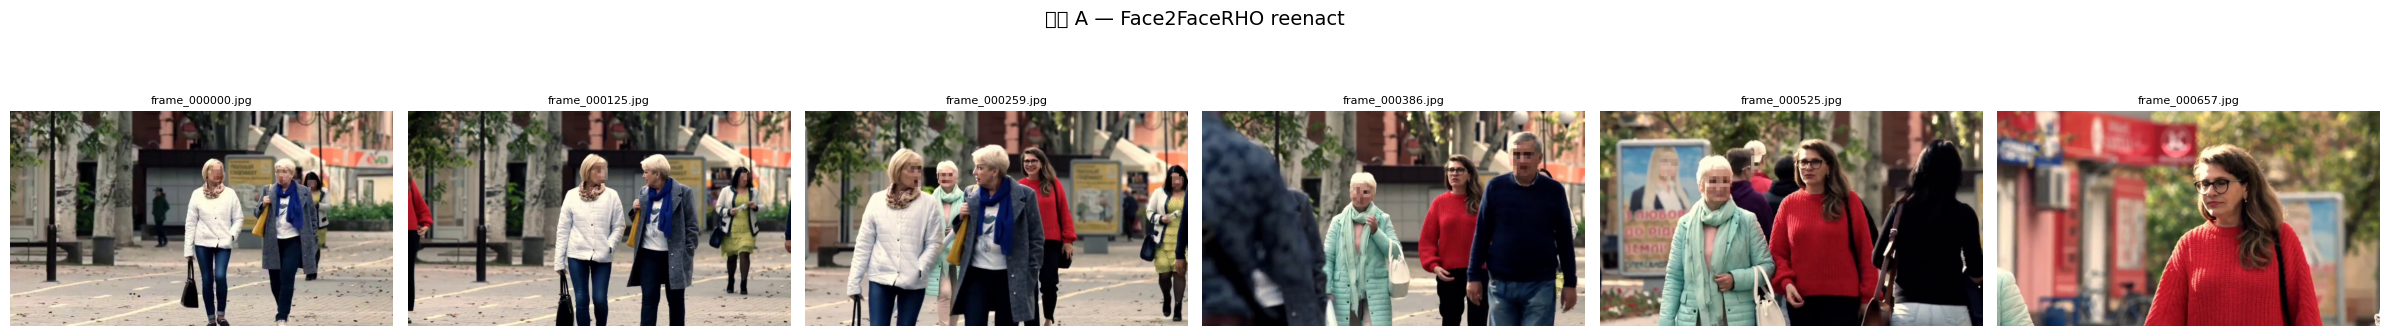

In [ ]:
import matplotlib.pyplot as plt
import glob
import cv2
import numpy as np

def preview_frames(frames_dir, n=6, title=''):
    """처리된 프레임 중 n개를 샘플링해서 시각화."""
    files = sorted(glob.glob(f'{frames_dir}/frame_*.jpg'))
    if not files:
        print(f"❌ {frames_dir} 에 프레임 없음")
        return
    step  = max(1, len(files) // n)
    picks = files[::step][:n]

    fig, axes = plt.subplots(1, len(picks), figsize=(4 * len(picks), 4))
    if len(picks) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=14)
    for ax, fp in zip(axes, picks):
        img = cv2.cvtColor(cv2.imread(fp), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(os.path.basename(fp), fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# 방식 B 미리보기 (빠르게 확인)
# preview_frames(OUTPUT_DIR_B, n=6, title='방식 B — face_alignment + seamlessClone')

# 방식 A 미리보기 (실행했을 경우)
if os.path.exists(OUTPUT_DIR_A) and glob.glob(f'{OUTPUT_DIR_A}/frame_*.jpg'):
    preview_frames(OUTPUT_DIR_A, n=6, title='방식 A — Face2FaceRHO reenact')

In [ ]:
# 특정 프레임 상세 비교: 원본 vs 방식 B
COMPARE_FRAME_IDX = 0  # 비교할 프레임 번호 (0부터)

orig_files  = sorted(glob.glob(f'{FRAMES_DIR}/frame_*.jpg'))
result_files = sorted(glob.glob(f'{OUTPUT_DIR_B}/frame_*.jpg'))

if orig_files and result_files:
    idx = min(COMPARE_FRAME_IDX, len(orig_files)-1)
    orig   = cv2.cvtColor(cv2.imread(orig_files[idx]),   cv2.COLOR_BGR2RGB)
    result = cv2.cvtColor(cv2.imread(result_files[idx]), cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(orig);   axes[0].set_title('원본 driving 프레임'); axes[0].axis('off')
    axes[1].imshow(result); axes[1].set_title('방식 B 결과');         axes[1].axis('off')
    plt.tight_layout()
    plt.show()

NameError: name 'OUTPUT_DIR_B' is not defined

---
## 💾 STEP 6 — 결과 다운로드

In [ ]:
from google.colab import files
import os

# 방식 B 영상 다운로드
if os.path.exists('/content/output_B_h264.mp4'):
    print("방식 B 영상 다운로드 중...")
    files.download('/content/output_B_h264.mp4')

# 방식 A 영상 다운로드
if os.path.exists('/content/output_A_h264.mp4'):
    print("방식 A 영상 다운로드 중...")
    files.download('/content/output_A_h264.mp4')

print("✅ 다운로드 완료")

방식 A 영상 다운로드 중...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 다운로드 완료


In [ ]:
# (선택) 결과 프레임 폴더를 zip으로 압축 후 다운로드
import shutil

# 방식 B 프레임 zip
if os.path.exists(OUTPUT_DIR_B):
    shutil.make_archive('/content/output_frames_B', 'zip', OUTPUT_DIR_B)
    files.download('/content/output_frames_B.zip')
    print("✅ 방식 B 프레임 zip 다운로드 완료")

# 방식 A 프레임 zip
if os.path.exists(OUTPUT_DIR_A) and glob.glob(f'{OUTPUT_DIR_A}/frame_*.jpg'):
    shutil.make_archive('/content/output_frames_A', 'zip', OUTPUT_DIR_A)
    files.download('/content/output_frames_A.zip')
    print("✅ 방식 A 프레임 zip 다운로드 완료")

---
## 🔧 STEP 7 — tracking_id별 source 이미지 변경 (나중에 사용)

현재는 모든 tracking_id에 동일한 source를 적용하고 있습니다.  
나중에 ID별로 다른 얼굴을 쓰고 싶을 때는 **STEP 3**의 `SOURCE_PER_ID`를 채우세요:

```python
SOURCE_PER_ID = {
    0:  '/content/person_A.jpg',   # tracking_id 0 → person_A
    2:  '/content/person_B.jpg',   # tracking_id 2 → person_B
    35: '/content/person_C.jpg',   # tracking_id 35 → person_C
    # 나머지 ID는 SOURCE_IMG_DEFAULT 사용
}
```

### 주요 tracking_id 등장 횟수
| tracking_id | 등장 프레임 수 | 비고 |
|:-----------:|:--------------:|------|
| 0  | 348 | 주인공급 |
| 2  | 142 | |
| 9  | 147 | |
| 35 | 134 | |
| 22 |  96 | |
| 기타 | 1~45 | 단역 |